**1 Установка зависимостей**

In [1]:
# Установка библиотек
!pip install librosa soundfile xgboost lightgbm catboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')


**Установка Датасета**

In [2]:
import os

# Основной путь к папке
base_path = 'Audio_Speech_Actors_01-24'

# Проверка существования
if os.path.exists(base_path):
    actors = os.listdir(base_path)
    print(f"✅ Папка найдена!")
    print(f"Количество папок Actor: {len(actors)}")
    print(f"Пример папок: {actors[:5]}")
else:
    print("❌ Папка Audio_Speech_Actors_01-24 не найдена")
    print("Текущая директория:", os.getcwd())
    print("Содержимое:", os.listdir('.')[:10])

✅ Папка найдена!
Количество папок Actor: 24
Пример папок: ['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05']


**Первичный анализ признаков**

Статистика по признакам:
    count  mean  std   min   25%   50%   75%   max
0  1422.0   0.0  1.0 -3.76 -0.67 -0.02  0.66  2.66
1  1422.0  -0.0  1.0 -3.36 -0.67  0.01  0.69  3.32
2  1422.0   0.0  1.0 -3.89 -0.59  0.04  0.68  2.48
3  1422.0   0.0  1.0 -3.57 -0.66 -0.00  0.66  3.01
4  1422.0   0.0  1.0 -3.17 -0.73  0.01  0.76  2.42
5  1422.0   0.0  1.0 -3.45 -0.65 -0.01  0.68  2.97
6  1422.0   0.0  1.0 -3.18 -0.72 -0.02  0.71  2.94
7  1422.0  -0.0  1.0 -3.13 -0.72  0.03  0.74  2.77
8  1422.0  -0.0  1.0 -4.04 -0.58  0.06  0.67  3.03
9  1422.0  -0.0  1.0 -4.41 -0.66 -0.02  0.64  6.39


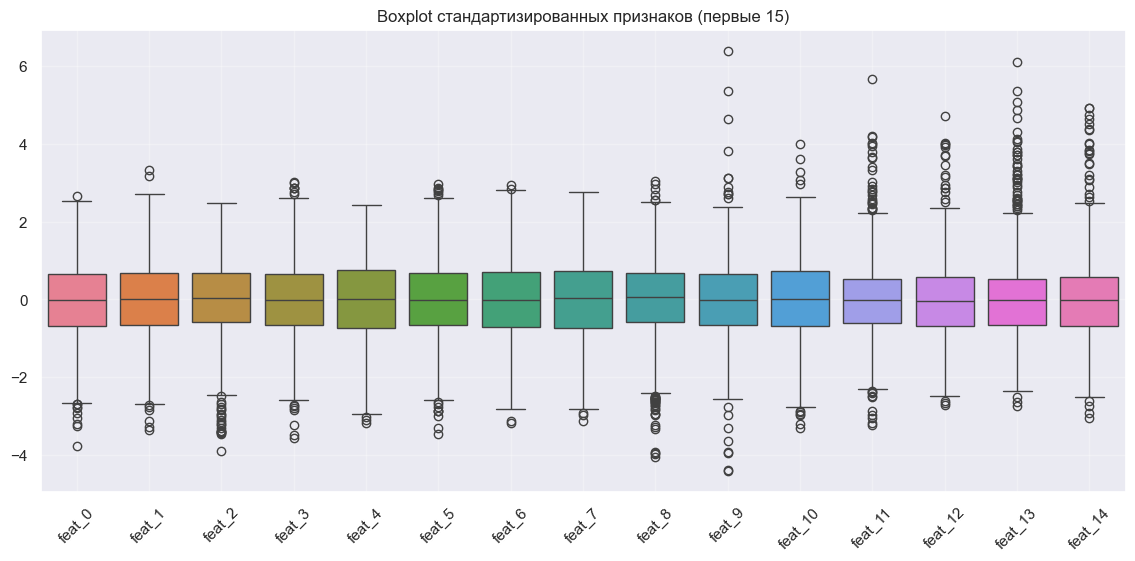

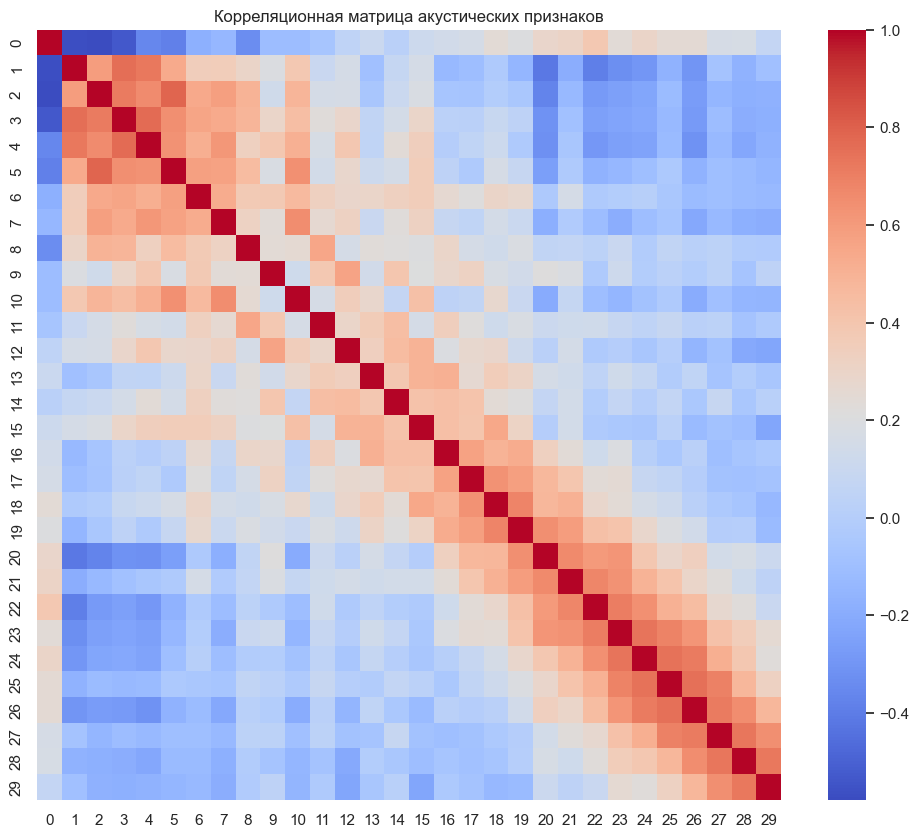

In [ ]:
# === Первичный анализ признаков ===

print("Статистика по признакам:")
print(pd.DataFrame(X).describe().round(2).T.head(10))  # первые 10 признаков

# Boxplot для первых нескольких признаков
plt.figure(figsize=(14, 6))
sns.boxplot(data=pd.DataFrame(X_scaled[:, :15], columns=[f'feat_{i}' for i in range(15)]))
plt.title('Boxplot стандартизированных признаков (первые 15)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Корреляционная матрица (выборочно)
corr_matrix = pd.DataFrame(X_scaled[:, :30]).corr()  # первые 30 признаков
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Корреляционная матрица акустических признаков')
plt.show()

**Стандартизация признаков + визуализация до/после**



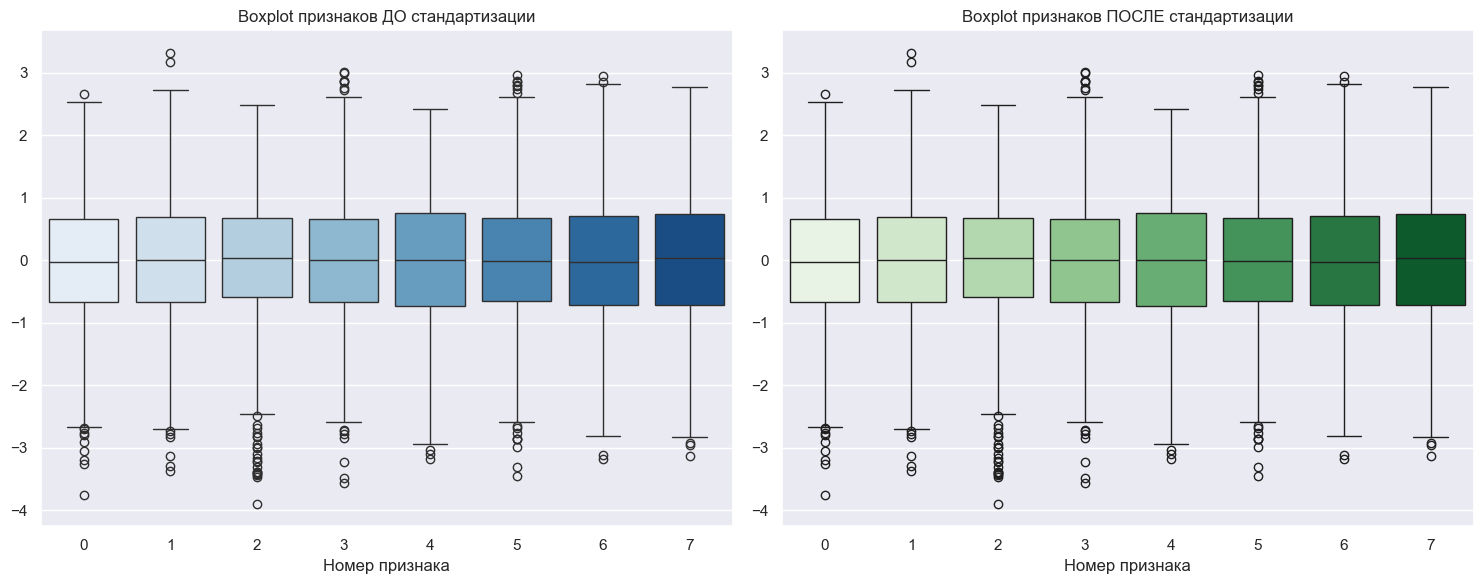

In [ ]:
# === Улучшенное сравнение стандартизации ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# До стандартизации
sns.boxplot(data=pd.DataFrame(X[:, :8]), ax=axes[0], palette="Blues")
axes[0].set_title('Boxplot признаков ДО стандартизации')
axes[0].set_xlabel('Номер признака')

# После стандартизации
sns.boxplot(data=pd.DataFrame(X_scaled[:, :8]), ax=axes[1], palette="Greens")
axes[1].set_title('Boxplot признаков ПОСЛЕ стандартизации')
axes[1].set_xlabel('Номер признака')

plt.tight_layout()
plt.show()

NameError: name 'X' is not defined

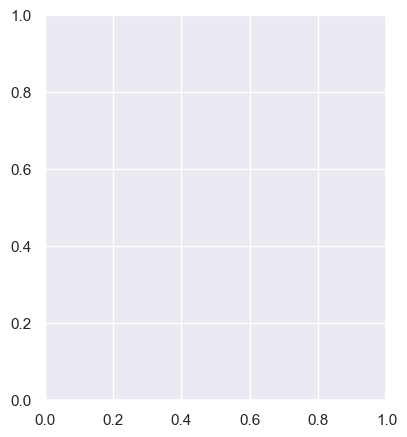

In [ ]:
# Сравнение распределения 3-х разных признаков
features_to_plot = [0, 5, 15]

plt.figure(figsize=(15, 5))
for i, feat in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.histplot(X[:, feat], kde=True, color='blue', label='До', alpha=0.6)
    sns.histplot(X_scaled[:, feat], kde=True, color='green', label='После', alpha=0.6)
    plt.title(f'Признак №{feat}')
    plt.legend()

plt.tight_layout()
plt.show()

**Парсинг названий файлов и извлечение признаков (MFCC + другие):**



In [8]:
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import time

def extract_features(file_path, max_pad_len=200):
    try:
        y, sr = librosa.load(file_path, sr=22050)
        
        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc = np.pad(mfcc, ((0,0), (0, max_pad_len - mfcc.shape[1])), 
                     mode='constant')[:, :max_pad_len]
        
        # Дополнительные признаки
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
        mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr), axis=1)
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr), axis=1)
        
        # Объединяем все признаки
        features = np.hstack([
            np.mean(mfcc, axis=1), 
            np.std(mfcc, axis=1),
            chroma,
            mel[:20],
            contrast
        ])
        return features
    except Exception as e:
        print(f"Ошибка с файлом {file_path}: {e}")
        return None


# === Основной сбор данных ===
print("Начинаем извлечение признаков из папки Audio_Speech_Actors_01-24...")

data = []
start_time = time.time()

for actor_folder in tqdm(os.listdir(base_path)):
    actor_path = os.path.join(base_path, actor_folder)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                file_path = os.path.join(actor_path, file)
                
                # Получаем эмоцию из названия файла
                try:
                    emotion_code = int(file.split('-')[2])
                    emotion_map = {
                        1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
                        5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'
                    }
                    emotion = emotion_map.get(emotion_code, 'unknown')
                except:
                    continue
                
                features = extract_features(file_path)
                if features is not None:
                    data.append({'file': file, 'emotion': emotion, 'features': features})

print(f"\n✅ Готово! Обработано файлов: {len(data)}")
print(f"Время обработки: {time.time() - start_time:.1f} секунд")

Начинаем извлечение признаков из папки Audio_Speech_Actors_01-24...


  0%|          | 0/24 [00:00<?, ?it/s]

Ошибка с файлом Audio_Speech_Actors_01-24\Actor_01\03-01-06-02-01-01-01.wav: index can't contain negative values


 17%|█▋        | 4/24 [00:42<02:25,  7.27s/it]

Ошибка с файлом Audio_Speech_Actors_01-24\Actor_05\03-01-02-02-01-01-05.wav: index can't contain negative values
Ошибка с файлом Audio_Speech_Actors_01-24\Actor_05\03-01-02-02-02-01-05.wav: index can't contain negative values


...

Ошибка с файлом Audio_Speech_Actors_01-24\Actor_23\03-01-04-02-02-02-23.wav: index can't contain negative values


 96%|█████████▌| 23/24 [01:45<00:03,  3.04s/it]

Ошибка с файлом Audio_Speech_Actors_01-24\Actor_24\03-01-04-02-02-02-24.wav: index can't contain negative values
Ошибка с файлом Audio_Speech_Actors_01-24\Actor_24\03-01-05-02-02-02-24.wav: index can't contain negative values


100%|██████████| 24/24 [01:48<00:00,  4.54s/it]


✅ Готово! Обработано файлов: 1422
Время обработки: 109.0 секунд


**Создание DataFrame и предобработка:**



In [9]:
# Создание DataFrame
df = pd.DataFrame(data, columns=['file', 'emotion', 'features'])
X = np.array([x for x in df['features']])
y = df['emotion']

print("Форма признаков:", X.shape)
print("\nРаспределение классов:")
print(y.value_counts())

# Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Форма признаков: (1422, 119)

Распределение классов:
emotion
happy        192
surprised    192
fearful      191
sad          190
angry        190
calm         189
disgust      182
neutral       96
Name: count, dtype: int64


**Разделение данных + базовые модели (≥7):**



In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, 
                                                    test_size=0.25, random_state=42, stratify=y_encoded)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Список моделей
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': lgb.LGBMClassifier(),
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    
    results[name] = {'Accuracy': acc, 'F1-macro': f1, 'Time': train_time}
    print(f"{name}: Accuracy={acc:.4f}, F1={f1:.4f}, Time={train_time:.2f}s")

Train: (1066, 119) Test: (356, 119)
LogisticRegression: Accuracy=0.5562, F1=0.5465, Time=0.15s
KNN: Accuracy=0.5534, F1=0.5316, Time=0.00s
RandomForest: Accuracy=0.6517, F1=0.6326, Time=3.12s
SVM: Accuracy=0.6067, F1=0.5828, Time=1.28s
XGBoost: Accuracy=0.6461, F1=0.6297, Time=2.85s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30345
[LightGBM] [Info] Number of data points in the train set: 1066, number of used features: 119
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.051688
[LightGBM] [Info] Start training from score -2.008824
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Info] Start training from score -2.695002
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.0

**Обучение**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='macro')
    
    results[name] = {'Accuracy': acc, 'F1-macro': f1, 'Time': train_time}
    print(f"{name:20} → Accuracy: {acc:.4f} | F1-macro: {f1:.4f} | Time: {train_time:.1f}s")

LogisticRegression   → Accuracy: 0.5562 | F1-macro: 0.5465 | Time: 0.1s
KNN                  → Accuracy: 0.5534 | F1-macro: 0.5316 | Time: 0.0s
RandomForest         → Accuracy: 0.6517 | F1-macro: 0.6326 | Time: 3.1s
SVM                  → Accuracy: 0.6067 | F1-macro: 0.5828 | Time: 1.0s
XGBoost              → Accuracy: 0.6461 | F1-macro: 0.6297 | Time: 2.8s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001654 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30345
[LightGBM] [Info] Number of data points in the train set: 1066, number of used features: 119
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.051688
[LightGBM] [Info] Start training from score -2.008824
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Info] Start training from score -2.695002
[LightGBM] [Info] Start tr

**Ансамбли (Voting, Bagging, Stacking):**

In [12]:
# Voting Classifier
voting = VotingClassifier(estimators=[
    ('rf', models['RandomForest']),
    ('xgb', models['XGBoost']),
    ('lgb', models['LightGBM']),
    ('svm', models['SVM'])
], voting='soft')

start = time.time()
voting.fit(X_train, y_train)
print("Voting time:", time.time()-start)

pred_v = voting.predict(X_test)
print("Voting Accuracy:", accuracy_score(y_test, pred_v))
print(classification_report(y_test, pred_v, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001661 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30345
[LightGBM] [Info] Number of data points in the train set: 1066, number of used features: 119
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.051688
[LightGBM] [Info] Start training from score -2.008824
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Info] Start training from score -2.695002
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

**GridSearch для улучшения (пример для RandomForest/XGBoost):**



In [13]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.625672414549603


**Сравнительная таблица**

In [14]:
# Voting Classifier
voting = VotingClassifier(estimators=[
    ('rf', models['RandomForest']),
    ('xgb', models['XGBoost']),
    ('lgb', models['LightGBM']),
    ('svm', models['SVM'])
], voting='soft', weights=[2, 2, 3, 1])   # можно подбирать веса

start = time.time()
voting.fit(X_train, y_train)
print(f"Voting Classifier обучен за {time.time() - start:.1f} секунд")

pred_v = voting.predict(X_test)
acc_v = accuracy_score(y_test, pred_v)
f1_v = f1_score(y_test, pred_v, average='macro')

print(f"\n🎯 Voting Classifier → Accuracy: {acc_v:.4f} | F1-macro: {f1_v:.4f}")
print(classification_report(y_test, pred_v, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30345
[LightGBM] [Info] Number of data points in the train set: 1066, number of used features: 119
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.051688
[LightGBM] [Info] Start training from score -2.008824
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Info] Start training from score -2.695002
[LightGBM] [Info] Start training from score -2.015842
[LightGBM] [Info] Start training from score -2.001855
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [20]:
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'F1-macro', 'Time']]
results_df.loc['Voting'] = [acc_v, f1_v, time.time()-start]

print("\n=== ИТОГОВАЯ ТАБЛИЦА ===")
print(results_df.round(4).sort_values(by='F1-macro', ascending=False))


=== ИТОГОВАЯ ТАБЛИЦА ===
                    Accuracy  F1-macro    Time
LightGBM              0.6966    0.6813  2.3013
Voting                0.6910    0.6776  9.2145
XGBoost               0.6489    0.6361  2.1475
RandomForest          0.6517    0.6326  1.5896
SVM                   0.6067    0.5828  1.0345
LogisticRegression    0.5562    0.5465  0.1044
KNN                   0.5534    0.5316  0.0013


**Визуализации (обязательно для отчета):**



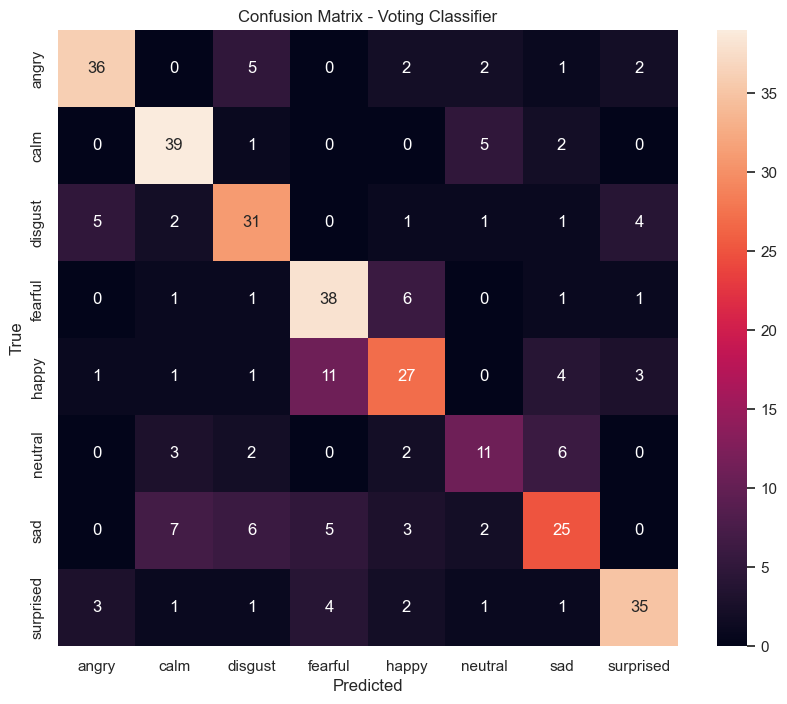

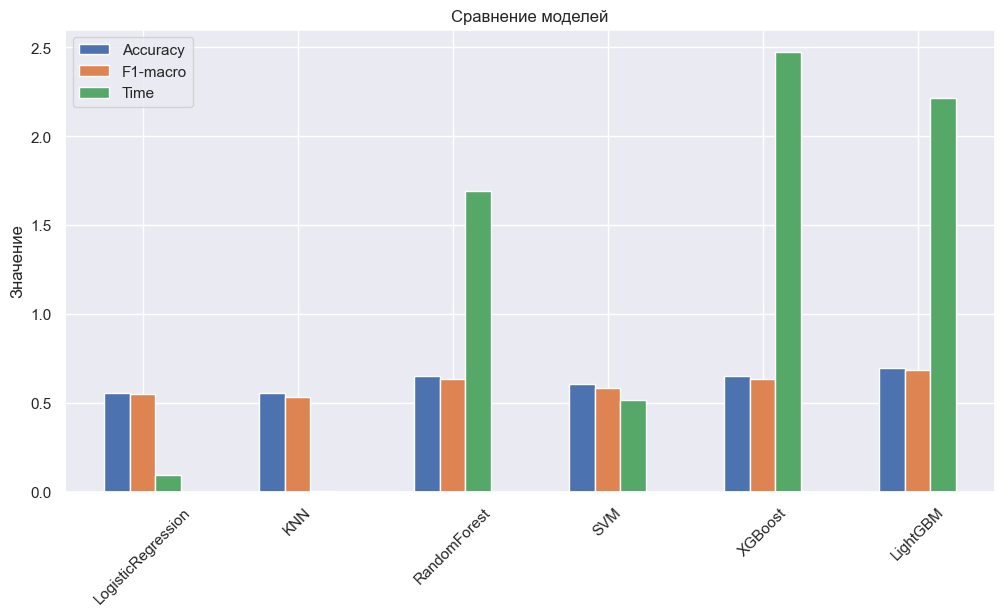

In [15]:
# Confusion Matrix для лучшей модели
cm = confusion_matrix(y_test, pred_v)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Voting Classifier')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

# Сравнение моделей
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(12,6))
plt.title('Сравнение моделей')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.show()

**k-fold Cross-Validation (для валидности):**



In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(voting, X_scaled, y_encoded, cv=cv, scoring='accuracy')
print("CV Accuracy mean:", cv_scores.mean())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30345
[LightGBM] [Info] Number of data points in the train set: 1137, number of used features: 119
[LightGBM] [Info] Start training from score -2.012268
[LightGBM] [Info] Start training from score -2.012268
[LightGBM] [Info] Start training from score -2.052542
[LightGBM] [Info] Start training from score -2.005711
[LightGBM] [Info] Start training from score -2.005711
[LightGBM] [Info] Start training from score -2.705415
[LightGBM] [Info] Start training from score -2.012268
[LightGBM] [Info] Start training from score -2.005711
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

**Сравнение моделей**

In [27]:
# === ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===

# Добавляем Voting Classifier в результаты
results['Voting Classifier'] = {
    'Accuracy': accuracy_score(y_test, pred_v),
    'F1-macro': f1_score(y_test, pred_v, average='macro'),
    'Time': time.time() - start   # время обучения Voting
}

# Создаём DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'F1-macro', 'Time']]
results_df = results_df.round(4)

# Сортируем по F1-macro (самая важная метрика для многоклассовой задачи)
results_df = results_df.sort_values(by='F1-macro', ascending=False)

print("\n" + "="*60)
print("                  ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*60)
print(results_df)
print("="*60)


                  ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ
                    Accuracy  F1-macro        Time
LightGBM              0.6966    0.6813      2.3013
Voting Classifier     0.6910    0.6776  12196.5411
XGBoost               0.6489    0.6361      2.1475
RandomForest          0.6517    0.6326      1.5896
SVM                   0.6067    0.5828      1.0345
LogisticRegression    0.5562    0.5465      0.1044
KNN                   0.5534    0.5316      0.0013
